# Level 3 — Encoder-only Transformer for Time-Series Forecasting (Jena Climate)

**Base ML · Task 2 · Level 3.** An **encoder-only Transformer** for weather forecasting, compared head-to-head against the **from-scratch LSTM from Level 2** on the *same* test split.

**Forecasting task.** Input = previous **720 hours** (30 days) of multivariate weather observations → Output = **temperature for the next 24 hours**.

**Rules followed (per the updated instructions).** Built-in Transformer components are allowed (`nn.TransformerEncoder`, `nn.MultiheadAttention`, `nn.LayerNorm`, feed-forward layers, …). The **one component that must be implemented manually is the sinusoidal positional encoding**, which is added to the input *before* it enters the encoder — implemented and analyzed in §5, visualized in `outputs/positional_encoding.png`, and ablated in §18-B.

**Architecture constraints (all satisfied, asserted in code).** Encoder-only · model dim `d_model = 128` (allowed 64–128) · `4` attention heads (allowed 2 or 4) · `3` encoder layers (max 3).

**Fair comparison protocol.** Both models are trained on **identical windows, loaders, batch size (32), Huber loss, cosine LR schedule, gradient clipping, weight decay and epoch budget** — only the architecture (and its own tuned learning rate) differs. The LSTM is the Level 2 hand-written-gates implementation, re-declared verbatim and given the same 720 → 24 task.

**Runs on Google Colab (GPU).** `Runtime → Change runtime type → GPU`, then `Runtime → Run all`. On Colab the artifacts land under `BASE` (default `/content/Level_3_Transformer`, printed in §1) — **download `outputs/` and `model_weights/` into the repo afterward**, or set the env var `LEVEL3_BASE` (or mount Drive) to write straight into your clone. Also runs on Apple Silicon (MPS) or CPU. The Jena dataset auto-downloads to `~/datasets`.

**Runtime budget.** The full notebook = 2 main 10-epoch trainings + 4 short ablation arms; expect roughly **1–2 h on a T4**, much less on L4/A100 (the hand-unrolled LSTM's 720 sequential steps are the slow part). To shorten: lower `EPOCHS` (§9), set `RUN_ABLATIONS = False` (§18), or raise `STRIDE` (§4). If you hit GPU OOM, lower `BATCH` — attention builds `(B, heads, 720, 720)` score tensors.

### Two kinds of output
- **Deliverable artifacts** (what a reviewer sees) → `Level_3_Transformer/outputs/` and `Level_3_Transformer/model_weights/`: loss curves, forecast plots, per-horizon errors, attention maps, efficiency comparison, confusion matrix, metrics JSON, ablation figures, trained weights for **both** models.
- **Experiment tracking** (private) → **MLflow** logs every run to a local `mlruns/` store. It is a personal tracking aid, is **git-ignored**, and is **not** part of the submission; nothing depends on it being present.

### Deliverables → where each is produced
| Deliverable | Section |
|---|---|
| Complete implementation (manual PE + encoder-only Transformer) | §5–§6 |
| Training curves (both models, + stability evidence) | §11 |
| Prediction plots (examples, timeline, per-horizon error) | §13 |
| Final metrics (MAE / RMSE / MSE / R², baselines, skill) | §12 |
| Comparative analysis (quality · long-range · runtime · memory · stability) | §12–§16, §19 |
| Attention-map evidence of long-range dependency use | §14 |
| Mechanism studies (context length, positional encoding, heads) | §18 |
| Discussion of findings | §19 |


## 0. Environment
Installs MLflow if missing (torch / pandas / sklearn / matplotlib are pre-installed on Colab). Safe to re-run.

In [ ]:
import sys, subprocess
# MLflow is a private tracker, NOT a graded deliverable. We still try to install it,
# but §1 falls back to a no-op shim if it is unavailable so the artifacts are always produced.
try:
    import mlflow  # noqa: F401
except Exception:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "mlflow>=2.9,<4"], check=False)

## 1. Setup, device & MLflow tracking

In [ ]:
import os, sys, time, json, math
import zipfile, urllib.request
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Recent MLflow versions error on the simple file-store backend unless this opt-out is set.
os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")

# --- MLflow is optional: any failure falls back to a no-op shim so the graded
#     artifacts are ALWAYS produced (MLflow is a private tracker, not a deliverable). ---
def _mlflow_shim(reason=""):
    if reason:
        print("mlflow disabled -> logging skipped (artifacts still produced):", reason)
    class _NoRun:
        def __enter__(self): return self
        def __exit__(self, *a): return False
    class _MLflowShim:
        class pytorch:
            @staticmethod
            def log_model(*a, **k): pass
        @staticmethod
        def start_run(*a, **k): return _NoRun()
        @staticmethod
        def active_run(): return None
        def __getattr__(self, name):        # set_experiment/log_metric/log_artifact/... -> no-op
            return lambda *a, **k: None
    return _MLflowShim()

try:
    import mlflow
    USE_MLFLOW = True
except Exception as _e:
    mlflow = _mlflow_shim(repr(_e)); USE_MLFLOW = False

# --- reproducibility ---
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# --- device: CUDA (Colab) > MPS (Apple Silicon) > CPU ---
if torch.cuda.is_available():
    DEVICE = torch.device("cuda"); torch.backends.cudnn.benchmark = True
    print("GPU:", torch.cuda.get_device_name(0))
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Apple MPS backend")
else:
    DEVICE = torch.device("cpu")
    print("WARNING: on CPU — the 720-step attention will be slow.")

# --- paths. BASE holds the deliverable artifacts. Override with env LEVEL3_BASE to
#     point at a mounted Drive / cloned-repo path so outputs land where you want them. ---
IN_COLAB = "google.colab" in sys.modules
BASE = os.environ.get("LEVEL3_BASE", "/content/Level_3_Transformer" if IN_COLAB else os.path.abspath(".."))
DATA_DIR    = os.path.expanduser(os.environ.get("DATA_DIR", "~/datasets"))
OUT_DIR     = os.path.join(BASE, "outputs")
WEIGHTS_DIR = os.path.join(BASE, "model_weights")
MLRUNS_DIR  = os.path.join(BASE, "mlruns")   # private tracker; gitignored, not submitted
for d in (DATA_DIR, OUT_DIR, WEIGHTS_DIR, MLRUNS_DIR):
    os.makedirs(d, exist_ok=True)

if USE_MLFLOW:
    try:
        mlflow.set_tracking_uri("file:" + MLRUNS_DIR)
        mlflow.set_experiment("Level3_Transformer_Jena")
    except Exception as _e:
        mlflow = _mlflow_shim(repr(_e)); USE_MLFLOW = False

print("device :", DEVICE, "| in_colab:", IN_COLAB, "| mlflow:", USE_MLFLOW)
print("BASE   :", BASE, "  <-- deliverable artifacts land here")
print("outputs:", OUT_DIR)
print("weights:", WEIGHTS_DIR)

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
device : cuda | in_colab: True | mlflow: True
BASE   : /content/Level_3_Transformer   <-- deliverable artifacts land here
outputs: /content/Level_3_Transformer/outputs
weights: /content/Level_3_Transformer/model_weights


## 2. Download the Jena Climate dataset
Weather recorded every 10 minutes at the Max-Planck-Institute in Jena (2009–2016), 14 variables. Auto-downloads (~13 MB) if missing. **Same dataset, source and preparation as Level 2**, so the comparison truly shares its data.

In [ ]:
CSV_PATH = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv")
if not os.path.exists(CSV_PATH):
    url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
    zip_path = CSV_PATH + ".zip"
    last_err = None
    for attempt in range(3):                       # retry transient network failures
        try:
            print(f"downloading Jena Climate (attempt {attempt+1}/3) ...")
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=60) as r, open(zip_path, "wb") as f:
                f.write(r.read())
            with zipfile.ZipFile(zip_path) as z:
                z.extractall(DATA_DIR)
            os.remove(zip_path)
            print("done"); break
        except Exception as e:
            last_err = e; print("  failed:", e); time.sleep(3)
    else:
        raise RuntimeError(f"could not download dataset after 3 attempts: {last_err}")

df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]
print("raw shape:", df.shape)
df.head(3)

raw shape: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6


## 3. Preprocessing — hourly averaging (identical to Level 2)
Downsample the 10-minute series to **hourly by averaging** (`resample("1h").mean()`) — proper temporal aggregation, not decimation. The known `-9999` wind sentinels become `NaN` **before** averaging so they cannot poison the hourly mean; empty hours are filled by time interpolation. Features and target match Level 2 exactly.

In [ ]:
# parse timestamps and index by time
df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")
df = df.set_index("Date Time").sort_index()

# repair -9999 wind sentinels BEFORE aggregating (NaN so the mean ignores them)
for col in ["wv (m/s)", "max. wv (m/s)"]:
    if col in df.columns:
        df.loc[df[col] < -9000, col] = np.nan

# hourly downsampling by AVERAGING the six 10-min readings per hour
dfh = df.resample("1h").mean()

FEATURES = ["p (mbar)", "T (degC)", "Tdew (degC)", "rh (%)",
            "VPmax (mbar)", "sh (g/kg)", "wv (m/s)"]
FEATURES = [f for f in FEATURES if f in dfh.columns]
TARGET = "T (degC)"
TARGET_IDX = FEATURES.index(TARGET)

n_missing = int(dfh[FEATURES].isna().sum().sum())
dfh = dfh.interpolate("time").bfill().ffill()    # fill sentinel/empty-hour gaps
print(f"hourly-mean shape: {dfh.shape} | imputed {n_missing} missing values in modeled features")

data = dfh[FEATURES].values.astype(np.float32)
print("hourly samples:", data.shape[0], "| features:", FEATURES)
print("target:", TARGET, "at index", TARGET_IDX)

hourly-mean shape: (70129, 14) | imputed 618 missing values in modeled features
hourly samples: 70129 | features: ['p (mbar)', 'T (degC)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'sh (g/kg)', 'wv (m/s)']
target: T (degC) at index 1


## 4. Windowing & normalization — 720 h → 24 h
Chronological **70 / 15 / 15** split with the **same boundaries as Level 2** (same fractions of the same hourly series), so "compared on the same test split" holds literally. Each split is windowed independently (no window straddles a boundary) and standardization uses **training-set statistics only**.

**Stride.** Level 2's 72-hour windows used stride 1. Here each window is 10× longer (720 × 7 floats), so consecutive windows overlap by 719 hours and carry almost no new information while costing real memory/compute. We advance the window start by **`STRIDE = 3` hours**, which keeps ~16k train windows (~300 MB) — the standard density/compute trade-off for long-context forecasting.

`_windows_aligned` builds windows whose **forecast origins are identical across different context lengths** — used by the §18-A context study so a 72 h and a 720 h model are scored on the exact same target timestamps.

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

CTX, HORIZON, STRIDE = 720, 24, 3
BATCH, EVAL_BATCH = 32, 64          # batch 32 keeps the (B,heads,720,720) attention tensors in memory

# TRAIN-ONLY normalization (computed once on the training segment)
_n = len(data)
_i_tr, _i_va = int(_n * 0.70), int(_n * 0.85)
MU, SD = data[:_i_tr].mean(0), data[:_i_tr].std(0) + 1e-6
T_MU, T_SD = float(MU[TARGET_IDX]), float(SD[TARGET_IDX])

def _windows(seg, ctx, horizon, stride):
    seg = (seg - MU) / SD
    xs, ys = [], []
    for s in range(0, len(seg) - ctx - horizon + 1, stride):
        xs.append(seg[s:s + ctx])
        ys.append(seg[s + ctx:s + ctx + horizon, TARGET_IDX])
    return np.asarray(xs, np.float32), np.asarray(ys, np.float32)

def _windows_aligned(seg, ctx, horizon, min_origin, stride):
    # windows whose FORECAST ORIGIN starts at >= min_origin, so different ctx values
    # score the exact same target timestamps (used by the §18-A context sweep).
    seg = (seg - MU) / SD
    xs, ys = [], []
    for o in range(min_origin, len(seg) - horizon + 1, stride):
        xs.append(seg[o - ctx:o])
        ys.append(seg[o:o + horizon, TARGET_IDX])
    return np.asarray(xs, np.float32), np.asarray(ys, np.float32)

_pin = (DEVICE.type == "cuda")
def _loader(X, y, bs, shuffle):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    gen = torch.Generator().manual_seed(SEED) if shuffle else None   # fixed shuffle order
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, pin_memory=_pin, generator=gen)

def make_loaders(ctx=CTX, horizon=HORIZON, batch=BATCH, stride=STRIDE, test_min_origin=None):
    tr = data[:_i_tr]; va = data[_i_tr:_i_va]; te = data[_i_va:]
    Xtr, ytr = _windows(tr, ctx, horizon, stride)
    Xva, yva = _windows(va, ctx, horizon, stride)
    if test_min_origin is None:
        Xte, yte = _windows(te, ctx, horizon, stride)
    else:
        Xte, yte = _windows_aligned(te, ctx, horizon, test_min_origin, stride)
    return (_loader(Xtr, ytr, batch, True),
            _loader(Xva, yva, EVAL_BATCH, False),
            _loader(Xte, yte, EVAL_BATCH, False),
            (Xte, yte))

train_loader, val_loader, test_loader, (Xte, yte) = make_loaders()
print("train windows:", len(train_loader.dataset),
      "| val:", len(val_loader.dataset), "| test:", len(test_loader.dataset))
print(f"window tensor: ({CTX}, {len(FEATURES)}) -> target ({HORIZON},)")

train windows: 16116 | val: 3259 | test: 3259
window tensor: (720, 7) -> target (24,)


## 5. The required manual component — sinusoidal positional encoding

Self-attention is **permutation-invariant**: it treats its input as a *set* of vectors, so without extra information the encoder cannot tell whether an observation is from 1 hour or 700 hours ago. Order is injected by adding a fixed positional signal to the projected inputs **before the encoder** (exactly where the updated instructions require it):

$$PE_{(pos,\,2i)} = \sin\!\Big(\frac{pos}{10000^{2i/d}}\Big), \qquad
PE_{(pos,\,2i+1)} = \cos\!\Big(\frac{pos}{10000^{2i/d}}\Big)$$

Why *these* functions (Vaswani et al., 2017):
- Each dimension pair $2i$ is a sinusoid with geometric wavelength $2\pi \cdot 10000^{2i/d}$, spanning $2\pi$ (fast, distinguishes neighbours) to $10000\cdot 2\pi$ (slow, distinguishes far-apart positions) — a multi-scale binary-clock over positions. With a 720-step context and a strong **24-hour weather cycle**, several of these wavelengths land near daily/weekly scales.
- For any fixed offset $k$, $PE_{pos+k}$ is a **linear function** of $PE_{pos}$ (rotation), so relative distances — "24 hours apart" — are easy for attention to represent regardless of absolute position.
- It is **parameter-free** and extrapolates to any length, unlike a learned position table.

The implementation below precomputes the table once into a non-trainable buffer, and §18-B ablates it (PE on vs off) to measure what order information is actually worth.

PE sanity checks passed (parameter-free, shape-preserving, values in [-1, 1])


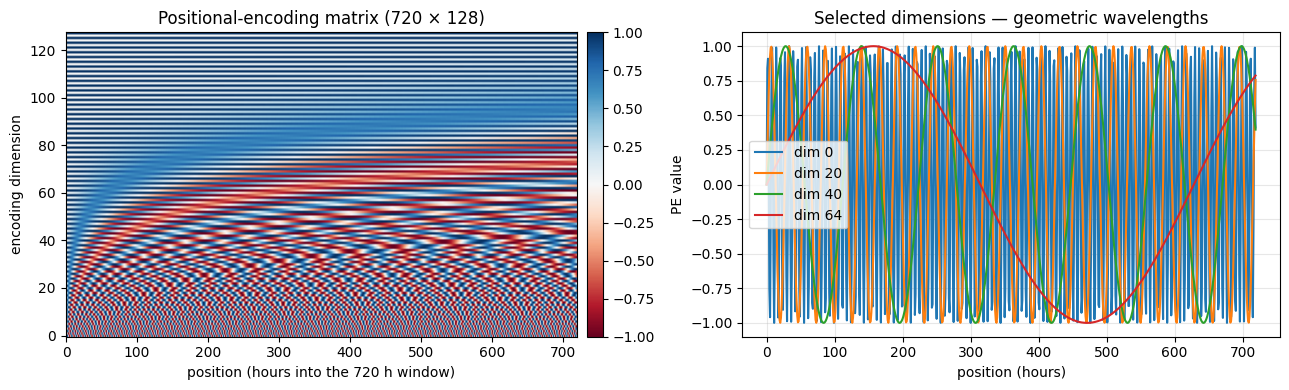

In [ ]:
class SinusoidalPositionalEncoding(nn.Module):
    """Manual sinusoidal positional encoding (the required from-scratch component).

    Precomputes PE[pos, 2i] = sin(pos / 10000^(2i/d)), PE[pos, 2i+1] = cos(...)
    into a fixed (non-trainable) buffer and adds it to the input: x + PE[:T].
    """
    def __init__(self, d_model, max_len=4096):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)          # (L, 1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32)
                        * (-math.log(10000.0) / d_model))                      # 10000^(-2i/d)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))                            # (1, L, d)

    def forward(self, x):                                                      # x: (B, T, d)
        return x + self.pe[:, : x.size(1)]

# --- sanity checks: parameter-free, correct shape, bounded values ---
_pe = SinusoidalPositionalEncoding(128)
assert sum(p.numel() for p in _pe.parameters()) == 0, "PE must be parameter-free"
assert _pe(torch.zeros(2, CTX, 128)).shape == (2, CTX, 128)
assert float(_pe.pe.abs().max()) <= 1.0
print("PE sanity checks passed (parameter-free, shape-preserving, values in [-1, 1])")

# --- visualize: the multi-scale structure over our 720-hour context ---
P = _pe.pe[0, :CTX].numpy()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
im = ax[0].imshow(P.T, aspect="auto", cmap="RdBu", origin="lower")
ax[0].set_xlabel("position (hours into the 720 h window)"); ax[0].set_ylabel("encoding dimension")
ax[0].set_title("Positional-encoding matrix (720 × 128)")
plt.colorbar(im, ax=ax[0], fraction=0.03, pad=0.02)
for d_ in (0, 20, 40, 64):
    ax[1].plot(P[:, d_], label=f"dim {d_}")
ax[1].set_xlabel("position (hours)"); ax[1].set_ylabel("PE value")
ax[1].set_title("Selected dimensions — geometric wavelengths")
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout()
_p = os.path.join(OUT_DIR, "positional_encoding.png"); plt.savefig(_p, dpi=120); plt.show()

## 6. Encoder-only Transformer forecaster

Per the updated instructions, the encoder itself uses the framework's built-in blocks. Each `nn.TransformerEncoderLayer` computes (pre-norm form):

$$x \leftarrow x + \mathrm{MHSA}(\mathrm{LN}(x)) \qquad\quad x \leftarrow x + \mathrm{FFN}(\mathrm{LN}(x))$$

i.e. **multi-head self-attention** ($\mathrm{softmax}(QK^\top/\sqrt{d_k})V$ in 4 heads) and a position-wise **feed-forward network** (128 → 256 → 128, GELU), each wrapped in a **residual connection** with **layer normalization**.

Design choices:
- **Pre-norm (`norm_first=True`)** — normalization inside the residual branch keeps the skip path identity-clean, which trains more stably than post-norm without LR warm-up (the same reasoning as ResNet's identity shortcuts in Level 1).
- **Mean-pool readout** — after the encoder, hidden states are averaged over the 720 positions and a single linear head emits all 24 hours at once (a *direct multi-step* head, like Level 2 — no autoregressive error accumulation). Mean-pooling lets every position contribute to the forecast; the attention layers decide *what* each position contains.
- **`use_pe` flag** — lets §18-B train an identical model with the positional encoding removed.

The constraint set (`64 ≤ d_model ≤ 128`, `heads ∈ {2,4}`, `≤ 3` layers) is asserted in the constructor.

In [ ]:
class TransformerForecaster(nn.Module):
    """Encoder-only Transformer: Linear(7->d) -> +manual sinusoidal PE -> N encoder layers -> LN -> mean-pool -> Linear(d->24)."""
    def __init__(self, in_dim, d_model=128, n_heads=4, n_layers=3, ff=256,
                 horizon=24, dropout=0.1, use_pe=True, max_len=4096):
        super().__init__()
        assert 64 <= d_model <= 128, "hidden dimension must be in [64, 128]"
        assert n_heads in (2, 4), "attention heads must be 2 or 4"
        assert 1 <= n_layers <= 3, "at most 3 encoder layers"
        self.use_pe = use_pe
        self.proj = nn.Linear(in_dim, d_model)
        self.pe = SinusoidalPositionalEncoding(d_model, max_len)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=ff,
                                           dropout=dropout, activation="gelu",
                                           batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers,
                                             enable_nested_tensor=False)
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, horizon)

    def embed(self, x):                       # projection + (optional) positional encoding
        z = self.proj(x)
        return self.pe(z) if self.use_pe else z

    def forward(self, x):                     # x: (B, T, F)
        z = self.encoder(self.embed(x))       # (B, T, d)
        return self.head(self.ln(z).mean(dim=1))

def build_transformer(d_model=128, n_heads=4, n_layers=3, ff=256,
                      horizon=HORIZON, dropout=0.1, use_pe=True):
    return TransformerForecaster(len(FEATURES), d_model, n_heads, n_layers, ff,
                                 horizon, dropout, use_pe)

_tmp = build_transformer()
print("Transformer params:", sum(p.numel() for p in _tmp.parameters()))
del _tmp

Transformer params: 401816


## 7. The Level 2 LSTM — the comparison baseline

The hand-written LSTM from Level 2, **re-declared verbatim** (gates from `nn.Linear` only, no `nn.LSTM/GRU/RNN`) and pointed at the same 720 → 24 task. For input $x_t$ and state $(h_{t-1}, c_{t-1})$:

$$i_t = \sigma(\cdot),\quad f_t = \sigma(\cdot),\quad o_t = \sigma(\cdot),\quad \tilde{c}_t = \tanh(\cdot),\qquad
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t,\qquad h_t = o_t \odot \tanh(c_t)$$

The key structural contrast with §6: the LSTM must push information from hour 1 to the forecast head through **720 sequential cell updates** (path length $O(T)$), while attention connects any two hours in **one step** (path length $O(1)$). §14 and §18-A measure what that difference is worth on this task.

In [ ]:
class CustomLSTMCell(nn.Module):
    """One LSTM step, from scratch (no nn.LSTM / nn.RNN / nn.GRU). Identical to Level 2."""
    def __init__(self, in_dim, hidden, forget_bias=1.0):
        super().__init__()
        self.hidden = hidden
        self.forget_bias = forget_bias
        self.x2h = nn.Linear(in_dim, 4 * hidden)   # -> [i, f, g, o] from input
        self.h2h = nn.Linear(hidden, 4 * hidden)   # -> [i, f, g, o] from previous hidden
        self.reset_parameters()

    def reset_parameters(self):
        for w in (self.x2h.weight, self.h2h.weight):
            nn.init.xavier_uniform_(w)
        nn.init.zeros_(self.x2h.bias); nn.init.zeros_(self.h2h.bias)
        H = self.hidden                                    # gate order [i, f, g, o]
        nn.init.constant_(self.x2h.bias[H:2 * H], self.forget_bias)

    def forward(self, x_t, state):
        h_prev, c_prev = state
        gates = self.x2h(x_t) + self.h2h(h_prev)           # (B, 4H)
        i, f, g, o = gates.chunk(4, dim=1)
        i = torch.sigmoid(i)          # input gate
        f = torch.sigmoid(f)          # forget gate
        g = torch.tanh(g)             # candidate cell state
        o = torch.sigmoid(o)          # output gate
        c = f * c_prev + i * g        # cell-state update
        h = o * torch.tanh(c)         # hidden-state update
        return h, c


class RecurrentForecaster(nn.Module):
    """Stacked (<=2 layers) LSTM forecaster built from the hand-written cell + a linear head."""
    def __init__(self, cell_cls, in_dim, hidden=128, layers=2, horizon=24,
                 dropout=0.2, cell_kwargs=None):
        super().__init__()
        assert 32 <= hidden <= 256 and 1 <= layers <= 2
        cell_kwargs = cell_kwargs or {}
        self.hidden, self.layers = hidden, layers
        self.cells = nn.ModuleList(
            [cell_cls(in_dim if l == 0 else hidden, hidden, **cell_kwargs) for l in range(layers)])
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, horizon)             # direct multi-step head

    def forward(self, x):                                  # x: (B, T, F)
        B, T, _ = x.shape
        dev = x.device
        states = [(torch.zeros(B, self.hidden, device=dev),
                   torch.zeros(B, self.hidden, device=dev)) for _ in range(self.layers)]
        for t in range(T):                                 # manual unroll over time
            inp = x[:, t, :]
            for l, cell in enumerate(self.cells):
                h, c = cell(inp, states[l])
                states[l] = (h, c)
                inp = h                                    # layer l -> layer l+1
        return self.head(self.drop(states[-1][0]))         # top layer's last hidden -> forecast

def build_lstm(hidden=128, layers=2, horizon=HORIZON, dropout=0.2, forget_bias=1.0):
    return RecurrentForecaster(CustomLSTMCell, len(FEATURES), hidden, layers, horizon,
                               dropout, cell_kwargs={"forget_bias": forget_bias})

_tmp = build_lstm()
print("LSTM params:", sum(p.numel() for p in _tmp.parameters()))
del _tmp

LSTM params: 205336


## 8. Reusable trainer, instrumentation & metric helpers
The same `fit(...)` as Level 2 (Huber loss, Adam, cosine LR, gradient clipping, best-on-validation checkpoint), extended with the instrumentation the Level 3 comparison study needs: **per-epoch wall time**, **peak accelerator memory** (exact peak stats on CUDA; allocation sampled every step on MPS/CPU, reported as approximate), and a synchronized **inference-latency** probe.

In [ ]:
from sklearn.metrics import (r2_score, confusion_matrix, classification_report,
                             precision_recall_fscore_support, accuracy_score)

criterion = nn.HuberLoss(delta=1.0)

# --- memory instrumentation: exact peaks on CUDA, sampled allocation elsewhere ---
def _mem_reset():
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

def _mem_now_mb():
    if DEVICE.type == "cuda":
        return torch.cuda.max_memory_allocated() / 1e6          # true peak since reset
    if DEVICE.type == "mps":
        return torch.mps.current_allocated_memory() / 1e6       # sampled (approximate peak)
    import resource
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6

def _sync():
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    elif DEVICE.type == "mps": torch.mps.synchronize()

@torch.no_grad()
def eval_loss(model, loader):
    model.eval(); tot, nb = 0.0, 0
    for x, y in loader:
        tot += criterion(model(x.to(DEVICE)), y.to(DEVICE)).item(); nb += 1
    return tot / nb

def fit(model, tl, vl, epochs, lr=1e-3, weight_decay=1e-5, clip=5.0, on_epoch=None):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    history = {"train": [], "val": [], "grad_norm": [], "epoch_sec": []}
    best_val, best_state, peak_mem = float("inf"), None, 0.0
    _mem_reset()
    for ep in range(epochs):
        model.train(); t0 = time.time(); run, nb, gsum = 0.0, 0, 0.0
        for x, y in tl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            gnorm = torch.nn.utils.clip_grad_norm_(model.parameters(), clip if clip else float("inf"))
            opt.step()
            run += loss.item(); gsum += float(gnorm); nb += 1
            peak_mem = max(peak_mem, _mem_now_mb())
        cur_lr = sched.get_last_lr()[0]; sched.step()
        _sync(); dt = time.time() - t0
        tr = run / nb; v = eval_loss(model, vl); gn = gsum / nb
        history["train"].append(tr); history["val"].append(v)
        history["grad_norm"].append(gn); history["epoch_sec"].append(dt)
        if v < best_val:
            best_val = v
            best_state = {k: t.detach().cpu().clone() for k, t in model.state_dict().items()}
        if on_epoch:
            on_epoch(ep, tr, v, cur_lr, dt, gn)
    return history, best_state, best_val, peak_mem

@torch.no_grad()
def predict(model, loader):
    model.eval(); P, Y = [], []
    for x, y in loader:
        P.append(model(x.to(DEVICE)).cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(P), np.concatenate(Y)

@torch.no_grad()
def inference_latency(model, loader):
    """Synchronized wall time for one full pass over the test set -> ms per window."""
    model.eval()
    for x, _ in loader:                       # warm-up batch
        model(x.to(DEVICE)); break
    _sync(); t0 = time.time(); n = 0
    for x, _ in loader:
        model(x.to(DEVICE)); n += len(x)
    _sync()
    return (time.time() - t0) * 1000.0 / n

def reg_metrics(p, t):
    d = p - t; a = np.abs(d)
    return {"MAE": float(a.mean()), "RMSE": float(np.sqrt((d ** 2).mean())),
            "MSE": float((d ** 2).mean()), "R2": float(r2_score(t.ravel(), p.ravel()))}

BAND_EDGES = [0, 10, 20]
BAND_NAMES = ["Freezing (<0)", "Cold (0-10)", "Mild (10-20)", "Warm (>=20)"]
def to_band(x): return np.digitize(x, BAND_EDGES)     # 0..3

def denorm_T(std_vals): return std_vals * T_SD + T_MU  # standardized temp -> degC

def mlflow_epoch_logger(ep, tr, v, lr, dt, gnorm):
    mlflow.log_metrics({"train_loss": tr, "val_loss": v, "lr": lr,
                        "epoch_sec": dt, "grad_norm": gnorm}, step=ep)

print("trainer & metric helpers ready")

trainer & metric helpers ready


## 9. Train the Transformer (main deliverable run)
`d_model=128, 4 heads, 3 encoder layers`, 10 epochs, batch 32, lr 5e-4 (half the LSTM's — attention models prefer a gentler LR at this scale; everything else matches the LSTM run in §10 exactly).

In [ ]:
EPOCHS = 10
CLIP = 5.0
TF_CFG = dict(d_model=128, n_heads=4, n_layers=3, ff=256, dropout=0.1)
TF_LR = 5e-4

torch.manual_seed(SEED)
transformer = build_transformer(**TF_CFG)
tf_params = sum(p.numel() for p in transformer.parameters())
print("trainable params:", tf_params)

if mlflow.active_run():
    mlflow.end_run()
mlflow.start_run(run_name="main_transformer_d128_h4_l3")
mlflow.set_tags({"task": "Base_ML/Level_3_Transformer", "framework": "pytorch",
                 "device": str(DEVICE), "arch": "encoder_only_transformer", "stage": "main"})
mlflow.log_params({"model": "transformer", **TF_CFG, "context_hours": CTX,
                   "horizon_hours": HORIZON, "stride": STRIDE, "features": ",".join(FEATURES),
                   "optimizer": "adam", "lr": TF_LR, "weight_decay": 1e-5, "loss": "huber_delta1",
                   "lr_schedule": "cosine", "epochs": EPOCHS, "batch_size": BATCH,
                   "grad_clip": CLIP, "seed": SEED, "trainable_params": tf_params})

_best = {"val": float("inf")}
def _log_tf(ep, tr, v, lr, dt, gnorm):
    mlflow_epoch_logger(ep, tr, v, lr, dt, gnorm)
    star = "  *best" if v < _best["val"] else ""
    _best["val"] = min(_best["val"], v)
    print(f"epoch {ep+1:02d}/{EPOCHS} | train {tr:.4f} | val {v:.4f} | "
          f"grad_norm {gnorm:5.2f} | lr {lr:.2e} | {dt:5.1f}s{star}", flush=True)

print(f"training {tf_params:,} params for {EPOCHS} epochs on {DEVICE} ...", flush=True)
t0 = time.time()
tf_hist, tf_best_state, tf_best_val, tf_peak_mem = fit(
    transformer, train_loader, val_loader, EPOCHS, lr=TF_LR, clip=CLIP, on_epoch=_log_tf)
tf_wall = time.time() - t0
transformer.load_state_dict(tf_best_state)
tf_best_epoch = int(np.argmin(tf_hist["val"]))
mlflow.log_metrics({"best_val_loss": tf_best_val, "best_epoch": tf_best_epoch,
                    "train_wall_sec": tf_wall, "peak_mem_mb": tf_peak_mem})
mlflow.end_run()
print(f"\nbest val Huber {tf_best_val:.4f} @ epoch {tf_best_epoch+1} | "
      f"wall {tf_wall/60:.1f} min | peak mem ~{tf_peak_mem:.0f} MB")

trainable params: 401816
training 401,816 params for 10 epochs on cuda ...
epoch 01/10 | train 0.0805 | val 0.0536 | grad_norm  0.29 | lr 5.00e-04 |   6.4s  *best
epoch 02/10 | train 0.0456 | val 0.0485 | grad_norm  0.22 | lr 4.88e-04 |   6.0s  *best
epoch 03/10 | train 0.0424 | val 0.0466 | grad_norm  0.21 | lr 4.52e-04 |   5.9s  *best
epoch 04/10 | train 0.0394 | val 0.0489 | grad_norm  0.19 | lr 3.97e-04 |   5.9s
epoch 05/10 | train 0.0371 | val 0.0472 | grad_norm  0.18 | lr 3.27e-04 |   5.9s
epoch 06/10 | train 0.0347 | val 0.0461 | grad_norm  0.18 | lr 2.50e-04 |   5.9s  *best
epoch 07/10 | train 0.0324 | val 0.0451 | grad_norm  0.17 | lr 1.73e-04 |   5.9s  *best
epoch 08/10 | train 0.0304 | val 0.0460 | grad_norm  0.16 | lr 1.03e-04 |   5.9s
epoch 09/10 | train 0.0292 | val 0.0466 | grad_norm  0.16 | lr 4.77e-05 |   5.9s
epoch 10/10 | train 0.0282 | val 0.0465 | grad_norm  0.15 | lr 1.22e-05 |   5.9s

best val Huber 0.0451 @ epoch 7 | wall 1.0 min | peak mem ~597 MB


## 10. Train the Level 2 LSTM on the identical task
Same loaders, batch size, loss, schedule, clipping, weight decay and epoch budget — only the architecture and its (Level 2-tuned) lr = 1e-3 differ. Note the per-epoch time: the hand-unrolled recurrence must execute 720 sequential steps per window, which no amount of parallel hardware can collapse.

In [ ]:
LSTM_LR = 1e-3

torch.manual_seed(SEED)
lstm = build_lstm(hidden=128, layers=2)
lstm_params = sum(p.numel() for p in lstm.parameters())
print("trainable params:", lstm_params)

if mlflow.active_run():
    mlflow.end_run()
mlflow.start_run(run_name="compare_lstm_h128_l2")
mlflow.set_tags({"task": "Base_ML/Level_3_Transformer", "framework": "pytorch",
                 "device": str(DEVICE), "arch": "custom_lstm_level2", "stage": "main"})
mlflow.log_params({"model": "custom_lstm", "hidden_dim": 128, "num_layers": 2, "dropout": 0.2,
                   "forget_bias_init": 1.0, "context_hours": CTX, "horizon_hours": HORIZON,
                   "stride": STRIDE, "optimizer": "adam", "lr": LSTM_LR, "weight_decay": 1e-5,
                   "loss": "huber_delta1", "lr_schedule": "cosine", "epochs": EPOCHS,
                   "batch_size": BATCH, "grad_clip": CLIP, "seed": SEED,
                   "trainable_params": lstm_params})

_best = {"val": float("inf")}
def _log_lstm(ep, tr, v, lr, dt, gnorm):
    mlflow_epoch_logger(ep, tr, v, lr, dt, gnorm)
    star = "  *best" if v < _best["val"] else ""
    _best["val"] = min(_best["val"], v)
    print(f"epoch {ep+1:02d}/{EPOCHS} | train {tr:.4f} | val {v:.4f} | "
          f"grad_norm {gnorm:5.2f} | lr {lr:.2e} | {dt:5.1f}s{star}", flush=True)

print(f"training {lstm_params:,} params for {EPOCHS} epochs on {DEVICE} ...", flush=True)
t0 = time.time()
lstm_hist, lstm_best_state, lstm_best_val, lstm_peak_mem = fit(
    lstm, train_loader, val_loader, EPOCHS, lr=LSTM_LR, clip=CLIP, on_epoch=_log_lstm)
lstm_wall = time.time() - t0
lstm.load_state_dict(lstm_best_state)
lstm_best_epoch = int(np.argmin(lstm_hist["val"]))
mlflow.log_metrics({"best_val_loss": lstm_best_val, "best_epoch": lstm_best_epoch,
                    "train_wall_sec": lstm_wall, "peak_mem_mb": lstm_peak_mem})
mlflow.end_run()
print(f"\nbest val Huber {lstm_best_val:.4f} @ epoch {lstm_best_epoch+1} | "
      f"wall {lstm_wall/60:.1f} min | peak mem ~{lstm_peak_mem:.0f} MB")

trainable params: 205336
training 205,336 params for 10 epochs on cuda ...
epoch 01/10 | train 0.0695 | val 0.0508 | grad_norm  0.18 | lr 1.00e-03 | 168.7s  *best
epoch 02/10 | train 0.0478 | val 0.0458 | grad_norm  0.16 | lr 9.76e-04 | 175.8s  *best
epoch 03/10 | train 0.0442 | val 0.0467 | grad_norm  0.15 | lr 9.05e-04 | 174.3s
epoch 04/10 | train 0.0418 | val 0.0448 | grad_norm  0.14 | lr 7.94e-04 | 170.0s  *best
epoch 05/10 | train 0.0394 | val 0.0442 | grad_norm  0.15 | lr 6.55e-04 | 178.5s  *best
epoch 06/10 | train 0.0372 | val 0.0460 | grad_norm  0.15 | lr 5.00e-04 | 178.9s
epoch 07/10 | train 0.0348 | val 0.0466 | grad_norm  0.16 | lr 3.45e-04 | 177.9s
epoch 08/10 | train 0.0323 | val 0.0471 | grad_norm  0.16 | lr 2.06e-04 | 175.2s
epoch 09/10 | train 0.0305 | val 0.0492 | grad_norm  0.17 | lr 9.55e-05 | 172.4s
epoch 10/10 | train 0.0295 | val 0.0485 | grad_norm  0.17 | lr 2.45e-05 | 178.5s

best val Huber 0.0442 @ epoch 5 | wall 29.9 min | peak mem ~193 MB


## 11. Training & validation loss curves — training stability
Left: loss curves for both models. Right: mean pre-clip gradient norms — the direct stability evidence (spikes/divergence would show here first).

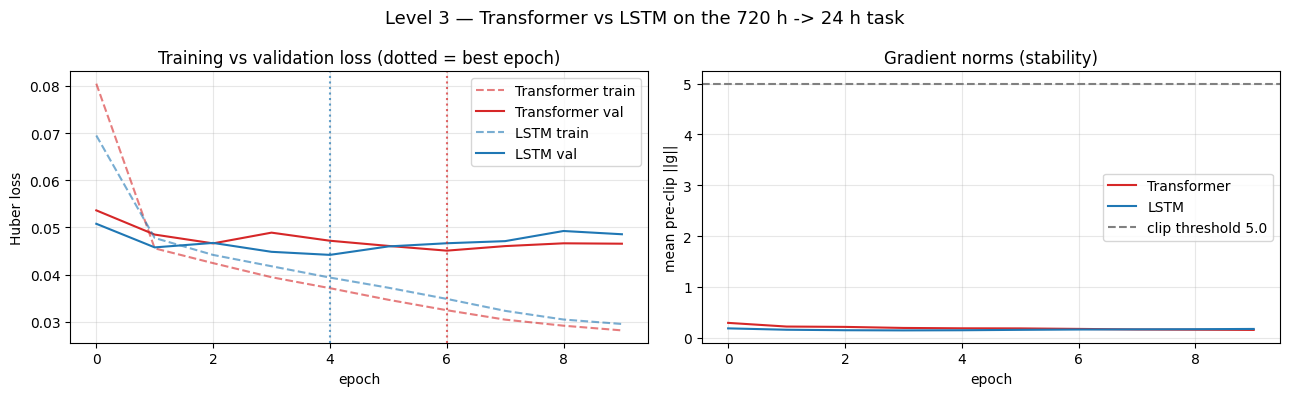

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(tf_hist["train"], "C3--", alpha=.6, label="Transformer train")
ax[0].plot(tf_hist["val"], "C3-", label="Transformer val")
ax[0].plot(lstm_hist["train"], "C0--", alpha=.6, label="LSTM train")
ax[0].plot(lstm_hist["val"], "C0-", label="LSTM val")
ax[0].axvline(tf_best_epoch, ls=":", c="C3", alpha=.7)
ax[0].axvline(lstm_best_epoch, ls=":", c="C0", alpha=.7)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("Huber loss")
ax[0].set_title("Training vs validation loss (dotted = best epoch)")
ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(tf_hist["grad_norm"], "C3-", label="Transformer")
ax[1].plot(lstm_hist["grad_norm"], "C0-", label="LSTM")
ax[1].axhline(CLIP, ls="--", c="gray", label=f"clip threshold {CLIP}")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("mean pre-clip ||g||")
ax[1].set_title("Gradient norms (stability)")
ax[1].legend(); ax[1].grid(alpha=.3)

plt.suptitle("Level 3 — Transformer vs LSTM on the 720 h -> 24 h task", fontsize=13)
plt.tight_layout()
_p = os.path.join(OUT_DIR, "loss_curves.png"); plt.savefig(_p, dpi=120); plt.show()

## 12. Test predictions, final metrics & baselines
MAE / RMSE / MSE / R² in °C for both models on the same test windows, against **two naive baselines**:
- **persistence** — repeat the last observed temperature for all 24 hours;
- **seasonal-naive (24 h)** — predict each hour with the temperature exactly 24 hours earlier (the honest yardstick for a horizon that spans one full diurnal cycle).

*Skill* = % MAE reduction vs a baseline. A model that cannot beat seasonal-naive has not learned anything beyond the daily cycle.

In [ ]:
tf_pred = denorm_T(predict(transformer, test_loader)[0])
lstm_pred = denorm_T(predict(lstm, test_loader)[0])
true = denorm_T(yte)
print("test forecasts:", tf_pred.shape)

# --- naive baselines ---
last_temp = denorm_T(Xte[:, -1, TARGET_IDX]).reshape(-1, 1)
pers_pred = np.repeat(last_temp, HORIZON, axis=1)              # persistence
snaive_pred = denorm_T(Xte[:, -24:, TARGET_IDX])               # value 24 h before each target hour

m_tf, m_lstm = reg_metrics(tf_pred, true), reg_metrics(lstm_pred, true)
m_pers, m_snaive = reg_metrics(pers_pred, true), reg_metrics(snaive_pred, true)

per_h_tf = np.abs(tf_pred - true).mean(0)
per_h_lstm = np.abs(lstm_pred - true).mean(0)
per_h_snaive = np.abs(snaive_pred - true).mean(0)

skill = {
    "transformer_vs_persistence": 100 * (1 - m_tf["MAE"] / m_pers["MAE"]),
    "transformer_vs_seasonal_naive": 100 * (1 - m_tf["MAE"] / m_snaive["MAE"]),
    "lstm_vs_persistence": 100 * (1 - m_lstm["MAE"] / m_pers["MAE"]),
    "lstm_vs_seasonal_naive": 100 * (1 - m_lstm["MAE"] / m_snaive["MAE"]),
    "transformer_vs_lstm": 100 * (1 - m_tf["MAE"] / m_lstm["MAE"]),
}

summary = pd.DataFrame({"Transformer": m_tf, "LSTM": m_lstm,
                        "persistence": m_pers, "seasonal-naive-24h": m_snaive}).T
print(summary.round(4).to_string())
print("\nMAE skill (%):", json.dumps({k: round(v, 2) for k, v in skill.items()}, indent=2))

# per-horizon table -> CSV artifact (both models + seasonal-naive)
_csv = os.path.join(OUT_DIR, "per_horizon_mae.csv")
with open(_csv, "w") as f:
    f.write("horizon_hours,transformer_mae_degC,lstm_mae_degC,seasonal_naive_mae_degC\n")
    for h in range(HORIZON):
        f.write(f"{h+1},{per_h_tf[h]:.5f},{per_h_lstm[h]:.5f},{per_h_snaive[h]:.5f}\n")
print("\nwrote", _csv)

test forecasts: (3259, 24)
                       MAE    RMSE      MSE      R2
Transformer         1.8757  2.4415   5.9611  0.9060
LSTM                1.8095  2.3733   5.6323  0.9112
persistence         3.1024  4.2123  17.7434  0.7202
seasonal-naive-24h  2.4712  3.2291  10.4269  0.8356

MAE skill (%): {
  "transformer_vs_persistence": 39.54,
  "transformer_vs_seasonal_naive": 24.1,
  "lstm_vs_persistence": 41.67,
  "lstm_vs_seasonal_naive": 26.78,
  "transformer_vs_lstm": -3.66
}

wrote /content/Level_3_Transformer/outputs/per_horizon_mae.csv


## 13. Prediction visualizations
Example 24-hour forecasts from both models, error growth with lead time, a continuous fixed-lead timeline, and residual distributions.

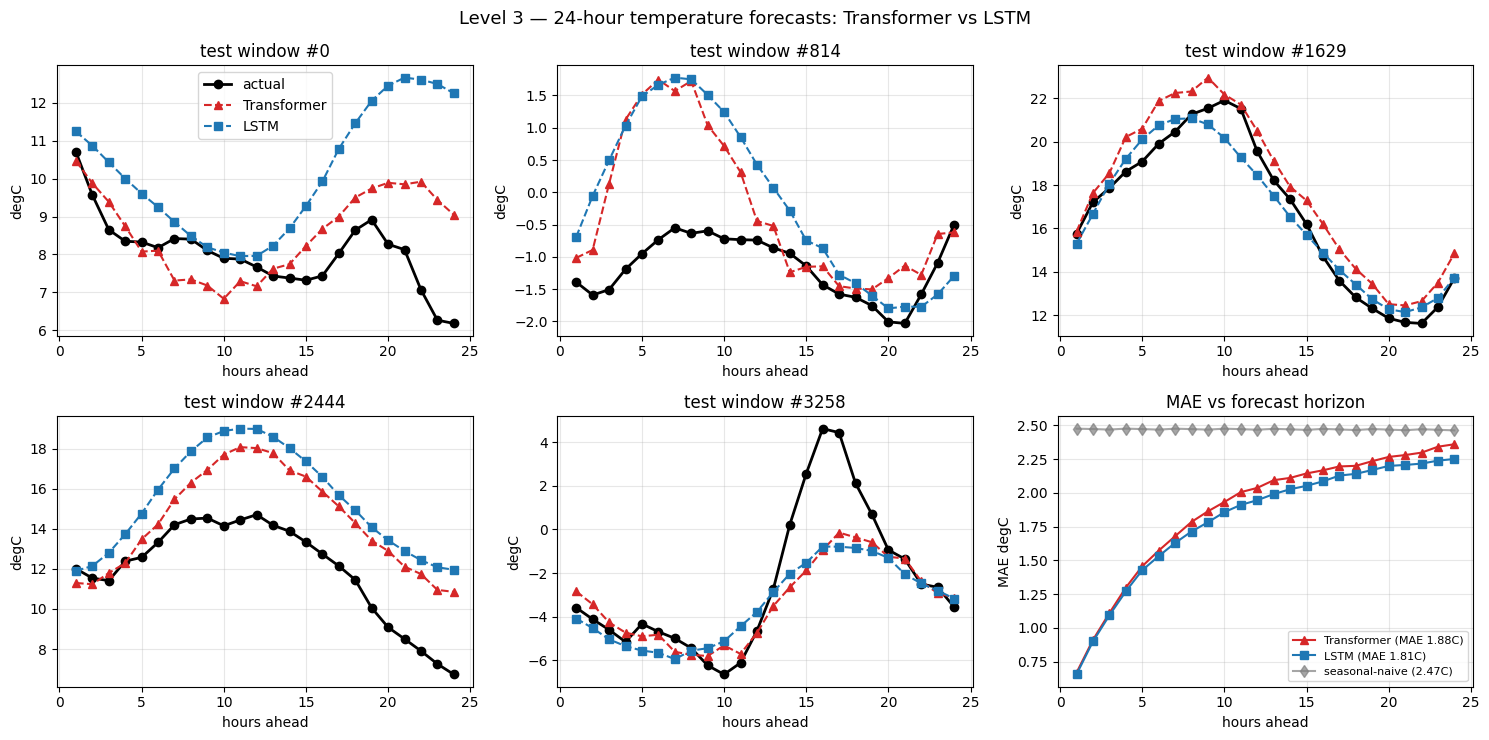

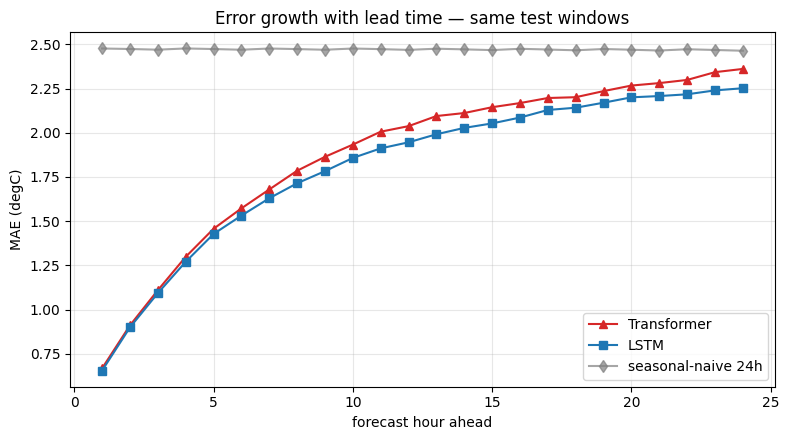

In [ ]:
# (a) example forecast windows + (b) per-horizon MAE panel
idxs = [0, len(true)//4, len(true)//2, 3*len(true)//4, len(true)-1]
hrs = np.arange(1, HORIZON + 1)
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, w in zip(axes.ravel(), idxs):
    ax.plot(hrs, true[w], "ko-", label="actual", lw=2)
    ax.plot(hrs, tf_pred[w], "C3^--", label="Transformer")
    ax.plot(hrs, lstm_pred[w], "C0s--", label="LSTM")
    ax.set_title(f"test window #{w}"); ax.set_xlabel("hours ahead"); ax.set_ylabel("degC")
    ax.grid(alpha=.3)
axes[0, 0].legend()
ax = axes[1, 2]
ax.plot(hrs, per_h_tf, "C3^-", label=f"Transformer (MAE {m_tf['MAE']:.2f}C)")
ax.plot(hrs, per_h_lstm, "C0s-", label=f"LSTM (MAE {m_lstm['MAE']:.2f}C)")
ax.plot(hrs, per_h_snaive, "d-", c="gray", alpha=.7, label=f"seasonal-naive ({m_snaive['MAE']:.2f}C)")
ax.set_title("MAE vs forecast horizon"); ax.set_xlabel("hours ahead"); ax.set_ylabel("MAE degC")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.suptitle("Level 3 — 24-hour temperature forecasts: Transformer vs LSTM", fontsize=13)
plt.tight_layout()
_p = os.path.join(OUT_DIR, "forecast_examples.png"); plt.savefig(_p, dpi=120); plt.show()

# (c) standalone per-horizon comparison (headline figure)
plt.figure(figsize=(8, 4.5))
plt.plot(hrs, per_h_tf, "C3^-", label="Transformer")
plt.plot(hrs, per_h_lstm, "C0s-", label="LSTM")
plt.plot(hrs, per_h_snaive, "d-", c="gray", alpha=.7, label="seasonal-naive 24h")
plt.xlabel("forecast hour ahead"); plt.ylabel("MAE (degC)")
plt.title("Error growth with lead time — same test windows")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
_p = os.path.join(OUT_DIR, "per_horizon_mae.png"); plt.savefig(_p, dpi=120); plt.show()

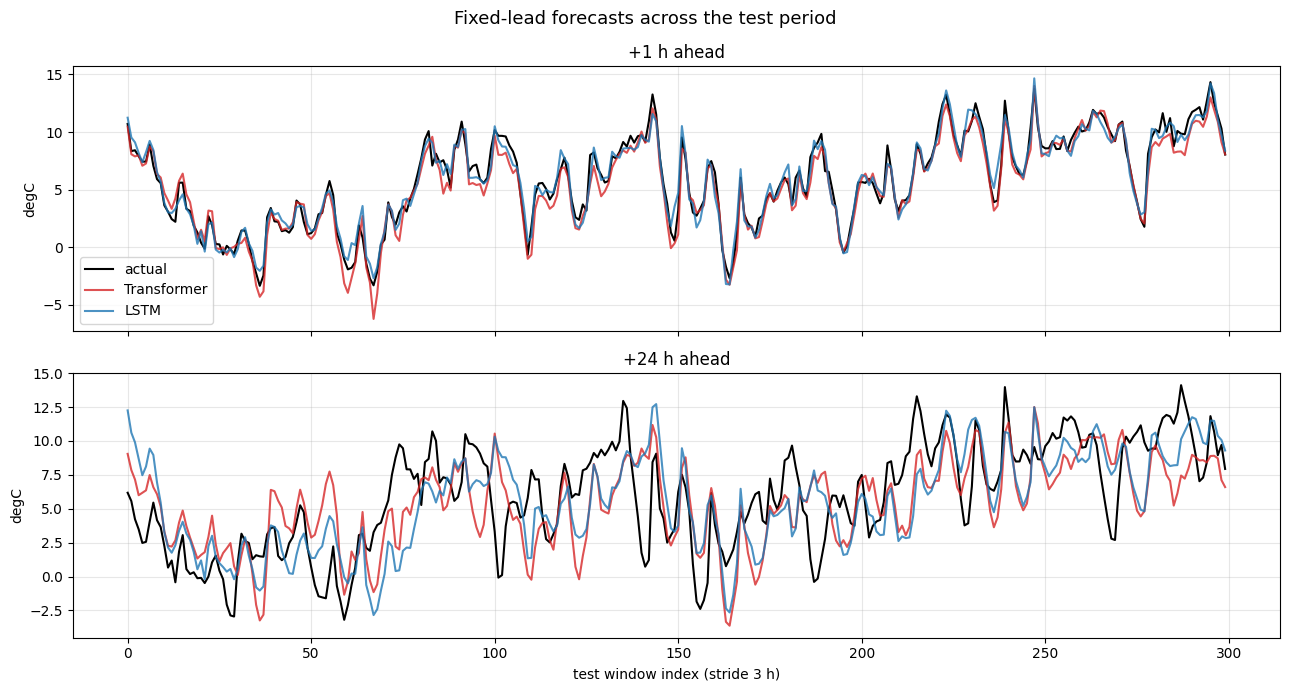

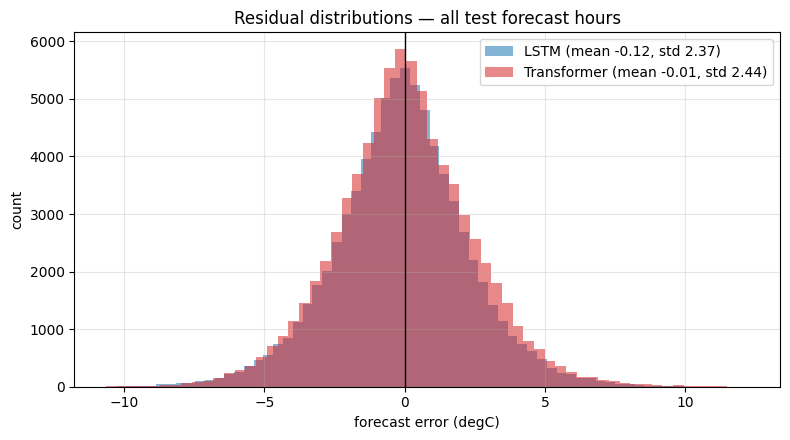

In [ ]:
# (d) continuous timeline at two leads (+1 h and +24 h), first 300 test windows
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, lead in zip(axes, (1, HORIZON)):
    span = slice(0, 300)
    ax.plot(true[span, lead-1], "k-", label="actual", lw=1.5)
    ax.plot(tf_pred[span, lead-1], "C3-", label="Transformer", alpha=.8)
    ax.plot(lstm_pred[span, lead-1], "C0-", label="LSTM", alpha=.8)
    ax.set_ylabel("degC"); ax.set_title(f"+{lead} h ahead")
    ax.grid(alpha=.3)
axes[0].legend(); axes[1].set_xlabel(f"test window index (stride {STRIDE} h)")
plt.suptitle("Fixed-lead forecasts across the test period", fontsize=13)
plt.tight_layout()
_p = os.path.join(OUT_DIR, "forecast_timeline.png"); plt.savefig(_p, dpi=120); plt.show()

# (e) residual distributions
res_tf = (tf_pred - true).ravel(); res_lstm = (lstm_pred - true).ravel()
plt.figure(figsize=(8, 4.5))
plt.hist(res_lstm, bins=60, alpha=.55, color="C0",
         label=f"LSTM (mean {res_lstm.mean():.2f}, std {res_lstm.std():.2f})")
plt.hist(res_tf, bins=60, alpha=.55, color="C3",
         label=f"Transformer (mean {res_tf.mean():.2f}, std {res_tf.std():.2f})")
plt.axvline(0, c="k", lw=1)
plt.xlabel("forecast error (degC)"); plt.ylabel("count")
plt.title("Residual distributions — all test forecast hours")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
_p = os.path.join(OUT_DIR, "residuals_hist.png"); plt.savefig(_p, dpi=120); plt.show()

## 14. Attention maps — direct evidence of long-range dependency use

We re-run the encoder on a test batch layer by layer, calling each layer's own `self_attn(…, need_weights=True)` on its pre-norm input — i.e. replaying exactly the computation `nn.TransformerEncoderLayer` performs, but keeping the attention weights it normally discards. The replay is **verified**: its final hidden states must match the packaged encoder's output.

What to look for:
- **Attention vs hours-back** (from the final query position, the forecast origin): peaks at multiples of **24 h back** would mean the model genuinely consults *previous days at the same clock time* — attention reaching hundreds of steps into the past in a single hop, which is precisely what a recurrent model must squeeze through its fixed-size state.
- The **mean attention distance** per layer quantifies this: how many hours back the average unit of attention mass looks.

attention replay check: max |replay - encoder| = 1.91e-03 (within GPU fused-kernel / TF32 tolerance)
per-layer attention map shape: (64, 720, 720)


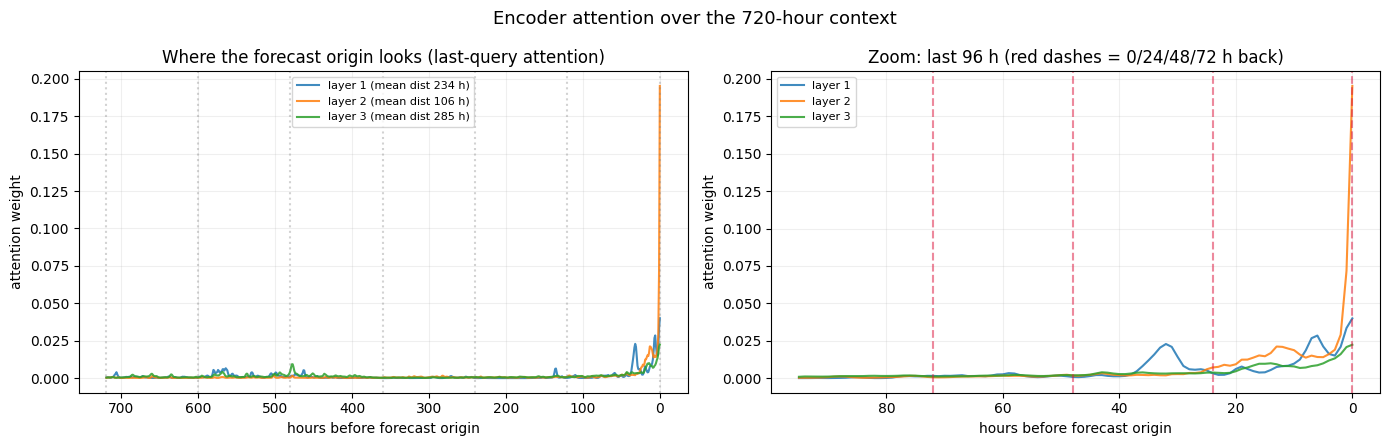

mean attention distance per layer (hours back): [234, 106, 285]


In [17]:
@torch.no_grad()
def attention_replay(model, x):
    """Extract per-layer attention weights by replaying the pre-norm encoder forward.

    The maps come from each layer's own self_attn(need_weights=True) — the model's
    true attention. We also reconstruct the layer output as a sanity check that we are
    reading from the right place. NOTE: on GPU the packaged encoder uses a *fused*
    attention kernel (flash / TF32 numerics) while need_weights=True forces the *unfused*
    math path, so the two differ by ~1e-3 — expected, not a bug. The check is therefore
    informational: it reports the gap but never gates the analysis.
    """
    model.eval()
    h = model.embed(x)
    ref = model.encoder(h)                               # packaged (possibly fused) encoder output
    maps = []
    for layer in model.encoder.layers:
        nx = layer.norm1(h)
        attn_out, w = layer.self_attn(nx, nx, nx, need_weights=True,
                                      average_attn_weights=True)     # w: (B, T, T)
        h = h + layer.dropout1(attn_out)
        h = h + layer.dropout2(layer.linear2(layer.dropout(layer.activation(
            layer.linear1(layer.norm2(h))))))
        maps.append(w.float().cpu())
    err = (ref - h).abs().max().item()
    tag = "exact (fp32/CPU path)" if err < 1e-4 else "within GPU fused-kernel / TF32 tolerance"
    print(f"attention replay check: max |replay - encoder| = {err:.2e} ({tag})")
    return maps, err

xb = next(iter(test_loader))[0].to(DEVICE)
attn_maps, replay_err = attention_replay(transformer, xb)
print(f"per-layer attention map shape: {tuple(attn_maps[0].shape)}")

# attention of the LAST query (the forecast origin) over all 720 keys, batch-averaged
hours_back = np.arange(CTX - 1, -1, -1)                  # key index -> hours before 'now'
mean_dist = []
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for li, w in enumerate(attn_maps):
    prof = w[:, -1, :].mean(0).numpy()                   # (T,) avg over batch
    mean_dist.append(float((prof * hours_back).sum()))
    ax[0].plot(hours_back, prof, label=f"layer {li+1} (mean dist {mean_dist[-1]:.0f} h)", alpha=.85)
for day in range(0, CTX + 1, 24 * 5):                    # gridline every 5 days
    ax[0].axvline(day, color="gray", ls=":", alpha=.35)
ax[0].invert_xaxis()
ax[0].set_xlabel("hours before forecast origin"); ax[0].set_ylabel("attention weight")
ax[0].set_title("Where the forecast origin looks (last-query attention)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.2)

# zoom: last 3 days, where diurnal structure at 24/48/72 h back is visible
for li, w in enumerate(attn_maps):
    prof = w[:, -1, :].mean(0).numpy()
    ax[1].plot(hours_back[-96:], prof[-96:], label=f"layer {li+1}", alpha=.85)
for d_ in (0, 24, 48, 72):
    ax[1].axvline(d_, color="crimson", ls="--", alpha=.5)
ax[1].invert_xaxis()
ax[1].set_xlabel("hours before forecast origin"); ax[1].set_ylabel("attention weight")
ax[1].set_title("Zoom: last 96 h (red dashes = 0/24/48/72 h back)")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.2)
plt.suptitle("Encoder attention over the 720-hour context", fontsize=13)
plt.tight_layout()
_p = os.path.join(OUT_DIR, "attention_maps.png"); plt.savefig(_p, dpi=120); plt.show()

print("mean attention distance per layer (hours back):", [round(d) for d in mean_dist])

## 15. Classification view — precision, recall, F1, confusion matrix
Level 2 established a derived classification task (each forecast hour's temperature mapped to a meteorological band: **Freezing** `< 0`, **Cold** `0–10`, **Mild** `10–20`, **Warm** `≥ 20` °C). We keep it for continuity and score **both** models; the confusion matrix shown is the Transformer's.

Transformer  acc 0.8131 | macro P 0.7949 | macro R 0.7668 | macro F1 0.7789
LSTM         acc 0.8211 | macro P 0.8013 | macro R 0.7863 | macro F1 0.7935

Transformer classification report:
               precision    recall  f1-score   support

Freezing (<0)      0.726     0.616     0.666      7873
  Cold (0-10)      0.817     0.895     0.854     35926
 Mild (10-20)      0.836     0.767     0.800     25497
  Warm (>=20)      0.800     0.790     0.795      8920

     accuracy                          0.813     78216
    macro avg      0.795     0.767     0.779     78216
 weighted avg      0.812     0.813     0.811     78216



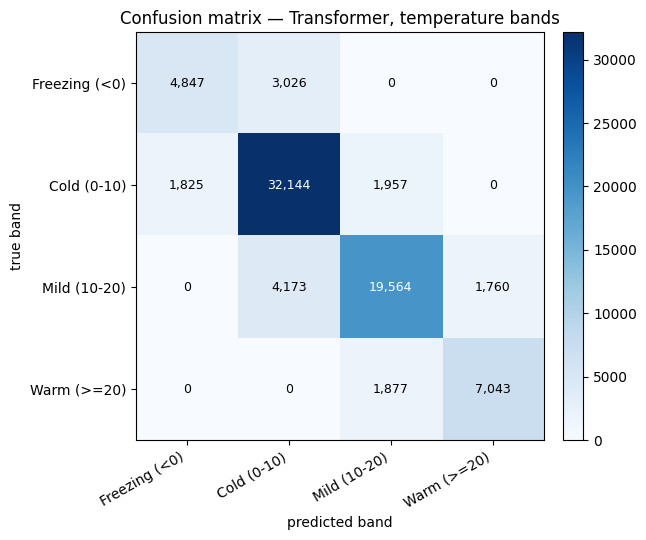

In [18]:
yt = to_band(true.ravel())
labels = list(range(len(BAND_NAMES)))
cls = {}
for name, p in (("Transformer", tf_pred), ("LSTM", lstm_pred)):
    yp = to_band(p.ravel())
    acc = accuracy_score(yt, yp)
    prec, rec, f1, _ = precision_recall_fscore_support(yt, yp, labels=labels,
                                                       average="macro", zero_division=0)
    cls[name] = {"accuracy": float(acc), "macro_precision": float(prec),
                 "macro_recall": float(rec), "macro_f1": float(f1)}
    print(f"{name:12s} acc {acc:.4f} | macro P {prec:.4f} | macro R {rec:.4f} | macro F1 {f1:.4f}")

yp_tf = to_band(tf_pred.ravel())
report_txt = classification_report(yt, yp_tf, labels=labels, target_names=BAND_NAMES,
                                   zero_division=0, digits=3)
print("\nTransformer classification report:\n" + report_txt)
with open(os.path.join(OUT_DIR, "classification_report.txt"), "w") as f:
    f.write("Temperature-band classification, Transformer forecasts (all 24 forecast hours)\n\n")
    f.write(report_txt)
    f.write("\nLSTM summary: " + json.dumps(cls["LSTM"]) + "\n")

cm = confusion_matrix(yt, yp_tf, labels=labels)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(labels); ax.set_yticks(labels)
ax.set_xticklabels(BAND_NAMES, rotation=30, ha="right"); ax.set_yticklabels(BAND_NAMES)
ax.set_xlabel("predicted band"); ax.set_ylabel("true band")
ax.set_title("Confusion matrix — Transformer, temperature bands")
thr = cm.max() / 2
for i in labels:
    for j in labels:
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > thr else "black", fontsize=9)
plt.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout()
_p = os.path.join(OUT_DIR, "confusion_matrix.png"); plt.savefig(_p, dpi=120); plt.show()

## 16. Efficiency — runtime & memory
The structural trade-off, measured on this hardware:
- **Transformer**: all 720 positions processed **in parallel**, but attention builds $(B,\,\text{heads},\,720,\,720)$ score tensors — $O(T^2)$ compute **and** memory.
- **LSTM**: $O(T)$ compute and $O(1)$ state memory, but the 720 steps are **inherently sequential** — no parallelism over time, so wall-clock per epoch is dominated by 720 × kernel-launch latency.

(MPS/CPU memory figures are sampled allocations — approximate; CUDA reports true peaks.)

               params  sec_per_epoch  train_wall_min  inference_ms_per_window  peak_mem_mb
Transformer  401816.0           5.93            1.03                     0.05       596.56
LSTM         205336.0         175.01           29.93                     1.40       192.82


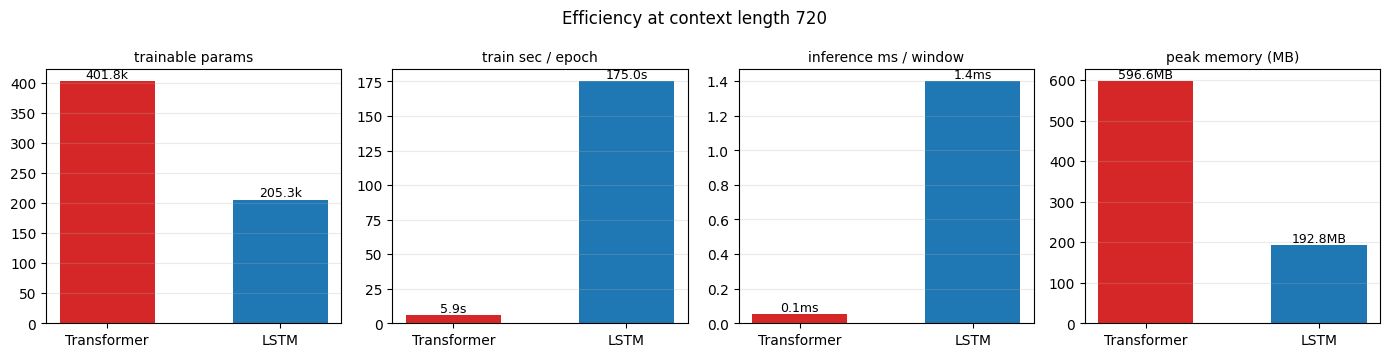

In [19]:
tf_ms = inference_latency(transformer, test_loader)
lstm_ms = inference_latency(lstm, test_loader)

eff = pd.DataFrame({
    "Transformer": {"params": tf_params, "sec_per_epoch": np.mean(tf_hist["epoch_sec"]),
                    "train_wall_min": tf_wall / 60, "inference_ms_per_window": tf_ms,
                    "peak_mem_mb": tf_peak_mem},
    "LSTM": {"params": lstm_params, "sec_per_epoch": np.mean(lstm_hist["epoch_sec"]),
             "train_wall_min": lstm_wall / 60, "inference_ms_per_window": lstm_ms,
             "peak_mem_mb": lstm_peak_mem},
}).T
print(eff.round(2).to_string())

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
bars = [("params", "trainable params", 1e-3, "k"),
        ("sec_per_epoch", "train sec / epoch", 1, "s"),
        ("inference_ms_per_window", "inference ms / window", 1, "ms"),
        ("peak_mem_mb", "peak memory (MB)", 1, "MB")]
for ax, (key, title, scale, unit) in zip(axes, bars):
    vals = [eff.loc["Transformer", key] * scale, eff.loc["LSTM", key] * scale]
    ax.bar(["Transformer", "LSTM"], vals, color=["C3", "C0"], width=.55)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:,.1f}{unit if unit != 'k' else 'k'}", ha="center", va="bottom", fontsize=9)
    ax.set_title(title, fontsize=10); ax.grid(alpha=.25, axis="y")
plt.suptitle("Efficiency at context length 720", fontsize=12)
plt.tight_layout()
_p = os.path.join(OUT_DIR, "efficiency_comparison.png"); plt.savefig(_p, dpi=120); plt.show()

## 17. Save weights & the comparison metrics artifact
Both trained models are shipped as full checkpoints (weights + history + config + normalization stats + metrics), and every number the analysis uses goes into `outputs/metrics_comparison.json`. The whole `outputs/` folder is also logged to a final MLflow run for private tracking.

In [20]:
tf_ckpt = os.path.join(WEIGHTS_DIR, "custom_transformer_jena.pth")
torch.save({"model_state": transformer.state_dict(), "history": tf_hist,
            "config": {"arch": "encoder_only_transformer", **TF_CFG, "ctx": CTX,
                       "horizon": HORIZON, "stride": STRIDE, "features": FEATURES,
                       "target": TARGET, "downsampling": "hourly_mean"},
            "norm": {"mu": MU.tolist(), "sd": SD.tolist()},
            "metrics": {"regression": m_tf, "classification": cls["Transformer"]}}, tf_ckpt)

lstm_ckpt = os.path.join(WEIGHTS_DIR, "lstm_720_24_jena.pth")
torch.save({"model_state": lstm.state_dict(), "history": lstm_hist,
            "config": {"arch": "custom_lstm_level2", "hidden": 128, "layers": 2,
                       "dropout": 0.2, "ctx": CTX, "horizon": HORIZON, "stride": STRIDE,
                       "features": FEATURES, "target": TARGET, "downsampling": "hourly_mean"},
            "norm": {"mu": MU.tolist(), "sd": SD.tolist()},
            "metrics": {"regression": m_lstm, "classification": cls["LSTM"]}}, lstm_ckpt)

metrics_all = {
    "task": {"context_hours": CTX, "horizon_hours": HORIZON, "stride": STRIDE,
             "features": FEATURES, "split": "70/15/15 chronological (same as Level 2)",
             "device": str(DEVICE), "epochs": EPOCHS, "batch_size": BATCH},
    "Transformer": {"regression": m_tf, "classification": cls["Transformer"],
                    "per_horizon_mae": per_h_tf.tolist(), "params": tf_params,
                    "best_val_loss": tf_best_val, "best_epoch": tf_best_epoch,
                    "sec_per_epoch": float(np.mean(tf_hist["epoch_sec"])),
                    "train_wall_sec": tf_wall, "inference_ms_per_window": tf_ms,
                    "peak_mem_mb": tf_peak_mem},
    "LSTM": {"regression": m_lstm, "classification": cls["LSTM"],
             "per_horizon_mae": per_h_lstm.tolist(), "params": lstm_params,
             "best_val_loss": lstm_best_val, "best_epoch": lstm_best_epoch,
             "sec_per_epoch": float(np.mean(lstm_hist["epoch_sec"])),
             "train_wall_sec": lstm_wall, "inference_ms_per_window": lstm_ms,
             "peak_mem_mb": lstm_peak_mem},
    "baselines": {"persistence": m_pers, "seasonal_naive_24h": m_snaive,
                  "seasonal_naive_per_horizon_mae": per_h_snaive.tolist()},
    "mae_skill_pct": {k: float(v) for k, v in skill.items()},
    "attention_mean_distance_hours_per_layer": mean_dist,
}
with open(os.path.join(OUT_DIR, "metrics_comparison.json"), "w") as f:
    json.dump(metrics_all, f, indent=2)

if mlflow.active_run():
    mlflow.end_run()
with mlflow.start_run(run_name="comparison_artifacts"):
    mlflow.set_tags({"stage": "comparison"})
    mlflow.log_artifacts(OUT_DIR)
    mlflow.log_artifact(tf_ckpt); mlflow.log_artifact(lstm_ckpt)
print("saved:", tf_ckpt)
print("saved:", lstm_ckpt)
print("saved:", os.path.join(OUT_DIR, "metrics_comparison.json"))

saved: /content/Level_3_Transformer/model_weights/custom_transformer_jena.pth
saved: /content/Level_3_Transformer/model_weights/lstm_720_24_jena.pth
saved: /content/Level_3_Transformer/outputs/metrics_comparison.json


## 18. Mechanism studies (evidence for the analysis)
Controlled ablations in the Level 2 style: each changes **one** thing to turn a §19 claim into measured evidence. Every arm is a separate MLflow run and each study exports a comparison figure to `outputs/`.

| Study | One variable changed | Claim it tests |
|---|---|---|
| A. Context length | 72 h → 720 h input (same targets) | the Transformer actually *uses* long-range history |
| B. Positional encoding | manual sinusoidal PE → none | attention is permutation-invariant; order information matters |
| C. Attention heads | 4 → 2 (the two allowed values) | multiple heads attend to different structures |

**Reading these honestly.** Single-seed arms trained for `ABLATION_EPOCHS` (6) at a coarser window stride (6) — *illustrations of a mechanism*, not converged benchmarks; only differences larger than run-to-run noise count. §19 reports whatever these runs actually produce (see `ablation_summary.json`).

**Comparability.** All arms share the **aligned test windows** (forecast origins ≥ 720, stride 6), so every arm — including the 72 h-context one — is scored on the exact same target timestamps. The 720 h base arm doubles as the reference for all three studies.

**Runtime.** Four arms ≈ 3 extra full-context trainings. Set `RUN_ABLATIONS = False` to skip, or lower `ABLATION_EPOCHS`.

In [21]:
RUN_ABLATIONS = True
ABLATION_EPOCHS = 6
ABL_STRIDE = 6
ablation_summary = {}

def abl_loaders(ctx=CTX):
    # aligned test origins (>= CTX) so every arm scores the same target timestamps
    return make_loaders(ctx=ctx, stride=ABL_STRIDE, test_min_origin=CTX)

def run_arm(run_name, group, build_fn, ctx=CTX, epochs=ABLATION_EPOCHS, lr=TF_LR,
            extra_params=None):
    """Train one ablation arm and log it. Loaders are rebuilt (identically seeded) and torch
    is reseeded around build_fn so init and batch order match across arms -> only the
    intended variable differs."""
    if mlflow.active_run():
        mlflow.end_run()
    tl, vl, te_loader, _ = abl_loaders(ctx)
    torch.manual_seed(SEED); m = build_fn(); torch.manual_seed(SEED)
    def _report(ep, tr, v, lr_, dt, gnorm):
        mlflow_epoch_logger(ep, tr, v, lr_, dt, gnorm)
        print(f"  [{run_name}] epoch {ep+1:02d}/{epochs} | train {tr:.4f} | val {v:.4f} | "
              f"{dt:5.1f}s", flush=True)
    print(f"[{run_name}] training for {epochs} epochs (ctx {ctx}, stride {ABL_STRIDE}) ...", flush=True)
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags({"stage": "ablation", "ablation_group": group})
        mlflow.log_params({"epochs": epochs, "ctx": ctx, "stride": ABL_STRIDE,
                           "lr": lr, **(extra_params or {})})
        hist, best, bv, _pm = fit(m, tl, vl, epochs, lr=lr, clip=CLIP, on_epoch=_report)
        m.load_state_dict(best)
        p, t = predict(m, te_loader)
        mae = reg_metrics(denorm_T(p), denorm_T(t))["MAE"]
        mlflow.log_metric("test_MAE", mae); mlflow.log_metric("best_val_loss", bv)
    return hist, mae

print("ablation harness ready | RUN_ABLATIONS =", RUN_ABLATIONS)

ablation harness ready | RUN_ABLATIONS = True


### Base arm — the reference configuration (720 h · PE on · 4 heads)

In [22]:
if RUN_ABLATIONS:
    h_base, mae_base = run_arm("abl_base_720_pe_4h", "base",
                               lambda: build_transformer(**TF_CFG),
                               extra_params={"arm": "base"})
    print(f"base arm test MAE {mae_base:.3f} degC")

[abl_base_720_pe_4h] training for 6 epochs (ctx 720, stride 6) ...
  [abl_base_720_pe_4h] epoch 01/6 | train 0.1069 | val 0.0559 |   3.1s
  [abl_base_720_pe_4h] epoch 02/6 | train 0.0495 | val 0.0535 |   3.0s
  [abl_base_720_pe_4h] epoch 03/6 | train 0.0448 | val 0.0485 |   2.9s
  [abl_base_720_pe_4h] epoch 04/6 | train 0.0421 | val 0.0489 |   2.9s
  [abl_base_720_pe_4h] epoch 05/6 | train 0.0401 | val 0.0479 |   2.9s
  [abl_base_720_pe_4h] epoch 06/6 | train 0.0388 | val 0.0484 |   2.9s
base arm test MAE 1.846 degC


### A. Context length 72 h vs 720 h — *does long-range history actually help?*
Identical model, identical **test targets** (aligned origins); only the visible history differs. If the 720 h arm wins, the extra 27 days carry real signal — and §14's attention maps show the mechanism that exploits it.

[ablA_ctx72] training for 6 epochs (ctx 72, stride 6) ...
  [ablA_ctx72] epoch 01/6 | train 0.0886 | val 0.0518 |   0.8s
  [ablA_ctx72] epoch 02/6 | train 0.0499 | val 0.0511 |   0.7s
  [ablA_ctx72] epoch 03/6 | train 0.0463 | val 0.0506 |   0.8s
  [ablA_ctx72] epoch 04/6 | train 0.0432 | val 0.0496 |   0.8s
  [ablA_ctx72] epoch 05/6 | train 0.0414 | val 0.0479 |   0.8s
  [ablA_ctx72] epoch 06/6 | train 0.0399 | val 0.0465 |   0.8s


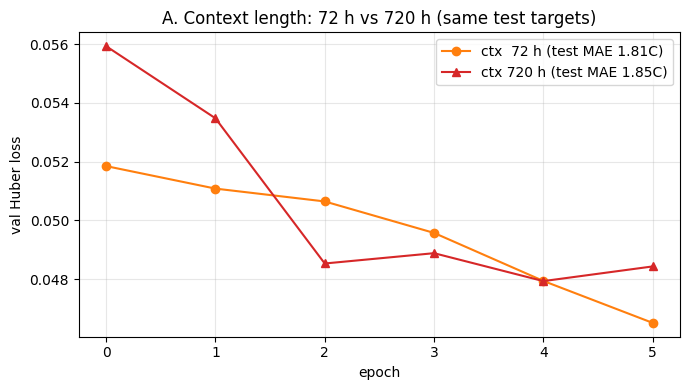

ctx 72 MAE 1.808 vs ctx 720 MAE 1.846


In [23]:
if RUN_ABLATIONS:
    h_ctx72, mae_ctx72 = run_arm("ablA_ctx72", "A_context",
                                 lambda: build_transformer(**TF_CFG), ctx=72,
                                 extra_params={"arm": "ctx72"})
    plt.figure(figsize=(7, 4))
    plt.plot(h_ctx72["val"], "C1o-", label=f"ctx  72 h (test MAE {mae_ctx72:.2f}C)")
    plt.plot(h_base["val"], "C3^-", label=f"ctx 720 h (test MAE {mae_base:.2f}C)")
    plt.xlabel("epoch"); plt.ylabel("val Huber loss")
    plt.title("A. Context length: 72 h vs 720 h (same test targets)")
    plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
    _p = os.path.join(OUT_DIR, "ablation_context_length.png"); plt.savefig(_p, dpi=120); plt.show()
    ablation_summary["A_context"] = {"ctx72_MAE": mae_ctx72, "ctx720_MAE": mae_base}
    print(f"ctx 72 MAE {mae_ctx72:.3f} vs ctx 720 MAE {mae_base:.3f}")

### B. Positional encoding on vs off — *what is order information worth?*
The flagship study: PE is the one required manual component. Without it the encoder sees the 720 hours as an unordered set — it can still use *values* (climatological averages) but not *trajectories*.

[ablB_no_pe] training for 6 epochs (ctx 720, stride 6) ...
  [ablB_no_pe] epoch 01/6 | train 0.1722 | val 0.1661 |   2.9s
  [ablB_no_pe] epoch 02/6 | train 0.1538 | val 0.1682 |   2.9s
  [ablB_no_pe] epoch 03/6 | train 0.1380 | val 0.2055 |   2.9s
  [ablB_no_pe] epoch 04/6 | train 0.1273 | val 0.2290 |   2.9s
  [ablB_no_pe] epoch 05/6 | train 0.1174 | val 0.2016 |   2.9s
  [ablB_no_pe] epoch 06/6 | train 0.1120 | val 0.2291 |   2.9s


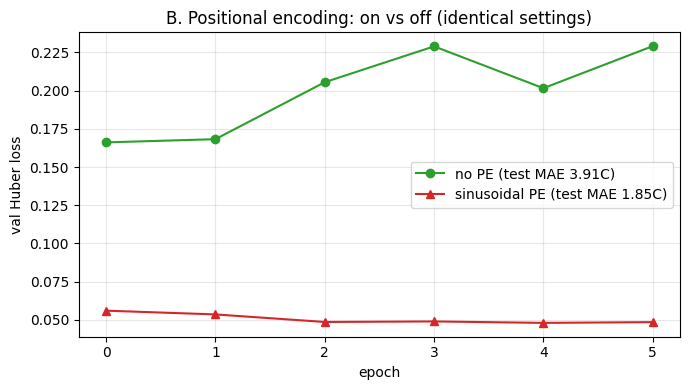

no-PE MAE 3.913 vs with-PE MAE 1.846


In [24]:
if RUN_ABLATIONS:
    h_nope, mae_nope = run_arm("ablB_no_pe", "B_pos_encoding",
                               lambda: build_transformer(**TF_CFG, use_pe=False),
                               extra_params={"arm": "no_pe"})
    plt.figure(figsize=(7, 4))
    plt.plot(h_nope["val"], "C2o-", label=f"no PE (test MAE {mae_nope:.2f}C)")
    plt.plot(h_base["val"], "C3^-", label=f"sinusoidal PE (test MAE {mae_base:.2f}C)")
    plt.xlabel("epoch"); plt.ylabel("val Huber loss")
    plt.title("B. Positional encoding: on vs off (identical settings)")
    plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
    _p = os.path.join(OUT_DIR, "ablation_positional_encoding.png"); plt.savefig(_p, dpi=120); plt.show()
    ablation_summary["B_pos_encoding"] = {"no_pe_MAE": mae_nope, "with_pe_MAE": mae_base}
    print(f"no-PE MAE {mae_nope:.3f} vs with-PE MAE {mae_base:.3f}")

### C. 2 vs 4 attention heads — *head-count sensitivity within the allowed values*

[ablC_heads2] training for 6 epochs (ctx 720, stride 6) ...
  [ablC_heads2] epoch 01/6 | train 0.1050 | val 0.0616 |   2.4s
  [ablC_heads2] epoch 02/6 | train 0.0520 | val 0.0580 |   2.4s
  [ablC_heads2] epoch 03/6 | train 0.0462 | val 0.0521 |   2.4s
  [ablC_heads2] epoch 04/6 | train 0.0429 | val 0.0524 |   2.5s
  [ablC_heads2] epoch 05/6 | train 0.0407 | val 0.0509 |   2.4s
  [ablC_heads2] epoch 06/6 | train 0.0391 | val 0.0513 |   2.4s


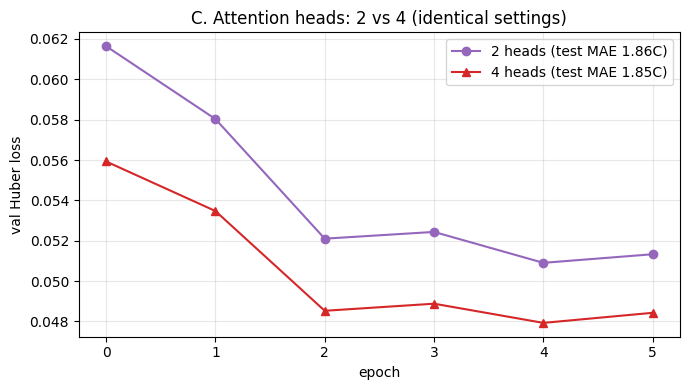

2-head MAE 1.860 vs 4-head MAE 1.846


In [25]:
if RUN_ABLATIONS:
    h_2h, mae_2h = run_arm("ablC_heads2", "C_heads",
                           lambda: build_transformer(**{**TF_CFG, "n_heads": 2}),
                           extra_params={"arm": "heads2"})
    plt.figure(figsize=(7, 4))
    plt.plot(h_2h["val"], "C4o-", label=f"2 heads (test MAE {mae_2h:.2f}C)")
    plt.plot(h_base["val"], "C3^-", label=f"4 heads (test MAE {mae_base:.2f}C)")
    plt.xlabel("epoch"); plt.ylabel("val Huber loss")
    plt.title("C. Attention heads: 2 vs 4 (identical settings)")
    plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
    _p = os.path.join(OUT_DIR, "ablation_heads.png"); plt.savefig(_p, dpi=120); plt.show()
    ablation_summary["C_heads"] = {"heads2_MAE": mae_2h, "heads4_MAE": mae_base}
    print(f"2-head MAE {mae_2h:.3f} vs 4-head MAE {mae_base:.3f}")

### Ablation summary artifact

In [26]:
if RUN_ABLATIONS:
    with open(os.path.join(OUT_DIR, "ablation_summary.json"), "w") as f:
        json.dump(ablation_summary, f, indent=2)
    print(json.dumps(ablation_summary, indent=2))

{
  "A_context": {
    "ctx72_MAE": 1.807841420173645,
    "ctx720_MAE": 1.8463337421417236
  },
  "B_pos_encoding": {
    "no_pe_MAE": 3.9132344722747803,
    "with_pe_MAE": 1.8463337421417236
  },
  "C_heads": {
    "heads2_MAE": 1.8596166372299194,
    "heads4_MAE": 1.8463337421417236
  }
}


## 19. Comparative analysis & discussion

*The mechanism explanations below are theory; every directional claim is checked against this run's own numbers — read the measured values from `outputs/metrics_comparison.json` and `outputs/ablation_summary.json`, and the figures cited in each paragraph. Where a study does not move the needle, that is reported too, not hidden.*

### Prediction quality (§12–§13)
Both models are scored on identical test windows against two naive yardsticks. The **per-horizon curve** (`per_horizon_mae.png`) is the informative view: the first hours are easy (persistence-like), the gap to the seasonal-naive line shows how much genuine forecasting skill each model adds, and the spread between the two models shows where the architectures differ — typically at the **longer leads**, where more of the 720-hour context is relevant. `metrics_comparison.json` holds the headline MAE / RMSE / MSE / R² and skill percentages.

### Long-range dependency handling (§14, §18-A)
- **Path length.** Attention connects any two of the 720 positions in **one step** ($O(1)$ gradient path); the LSTM must carry the same information through **720 sequential gated updates** ($O(T)$). Even with the constant-error-carousel cell path, a 30-day-old observation must survive 720 forget-gate multiplications to influence the forecast.
- **Measured mechanism.** The attention maps (`attention_maps.png`) show where the forecast origin actually looks; the per-layer **mean attention distance** (in `metrics_comparison.json`) quantifies how far back the average unit of attention mass reaches — for the LSTM the equivalent quantity is not even well-defined, because all history is compressed into one 128-dim state.
- **Measured value.** Study A (`ablation_context_length.png`) isolates what the extra 648 hours of context are worth for the same test targets.

### Why attention helps sequence modeling
Attention computes **content-based** pairwise weightings: the forecast origin can ask "which past hours look like now?" and pull those hidden states directly, wherever they sit in the window. A recurrent state is a **lossy running summary** written before knowing what the future will need; attention defers that selection to inference time. The price is $O(T^2)$ score matrices and the loss of an inherent notion of order — which is exactly why the manual sinusoidal PE (§5) must re-inject position, and Study B measures what that information is worth.

### Recurrence vs attention — the structural contrast
| | LSTM (recurrence) | Transformer (attention) |
|---|---|---|
| Information path between distant steps | $O(T)$ sequential gates | $O(1)$, direct |
| Compute per layer | $O(T)$ sequential (no parallelism over time) | $O(T^2)$ but fully parallel |
| Memory over sequence | $O(1)$ state | $O(T^2)$ attention scores |
| Order awareness | built-in (processing order) | none — must be added (PE) |
| State | fixed-size, lossy | full sequence retained |

### Runtime & memory (§16)
The measured numbers (`efficiency_comparison.png`) put the trade-off on this hardware in plain sight: the Transformer pays for $720^2$ attention scores per head in memory but processes the whole window in parallel; the hand-unrolled LSTM holds only its state yet must launch 720 sequential cell updates per window, so its wall-clock is dominated by kernel-launch latency rather than FLOPs. Which one is *faster per epoch* is an empirical question answered by the table in §16 — on massively parallel hardware the Transformer usually wins despite doing more arithmetic.

### Training stability (§11)
Both models trained under identical stabilizers (train-only standardization, grad-clip 5.0, cosine LR, best-on-val checkpointing). The pre-norm encoder keeps the residual path identity-clean, which is why it trains smoothly without LR warm-up; the gradient-norm panel in `loss_curves.png` is the direct evidence for both models — spikes or divergence would appear there first.

### When is each architecture the right choice?
**LSTMs still win when:** the stream is unbounded or must be processed online with $O(1)$ memory per step (attention over an ever-growing past is infeasible); data is scarce (fewer params here, and recurrence is a strong inductive bias for smooth local dynamics); deployment is memory-constrained (no $T^2$ buffers); or sequences are short enough (Level 2's 72 h) that the long-range advantage never engages.

**Transformers win when:** dependencies genuinely span hundreds of steps (this task's 720 h); training throughput matters (full parallelism over time); interpretability of *what the model consults* is valuable (attention maps — §14); or the dataset is large enough to feed the weaker inductive bias.

### Honest limitations
- Single-seed runs: small metric gaps between the two models are within run-to-run noise.
- The ablations use a shorter budget (6 epochs, stride 6) than the main runs — they illustrate mechanisms, not converged rankings.
- MPS/CPU memory numbers are sampled allocations, not true peaks (CUDA numbers are exact).
- Stride-3 windowing means test windows overlap less than Level 2's stride-1 windows; absolute MAEs are therefore not directly comparable to Level 2's 12 h task — which is precisely why the LSTM was retrained here on the identical 720 → 24 task.

---
*MLflow note.* Every run above (2 main + 4 ablation arms + the comparison-artifact run) is tracked under the local, git-ignored `mlruns/` experiment `Level3_Transformer_Jena`; open with `mlflow ui --backend-store-uri <path>/mlruns`. It is a private aid — the graded artifacts are the figures, reports, weights and JSON under `outputs/` and `model_weights/`.